# 🌸 Iris Flower Classification
### Oasis Infobyte Data Science Internship — Task 1
**Name:** Sadiya Anmol  
**Track:** Data Science  
**Dataset:** Iris (built-in sklearn)

In [2]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 1. Load Dataset & Exploratory Data Analysis (EDA)

In [3]:
# Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (150, 5)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Data Inspection

In [4]:
# Check data types and null values
print("Data Types:\n", df.dtypes)
print("\nNull Values:\n", df.isnull().sum())
print("\nDescriptive Statistics:")
df.describe()

Data Types:
 sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object

Null Values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 3. Visualizations

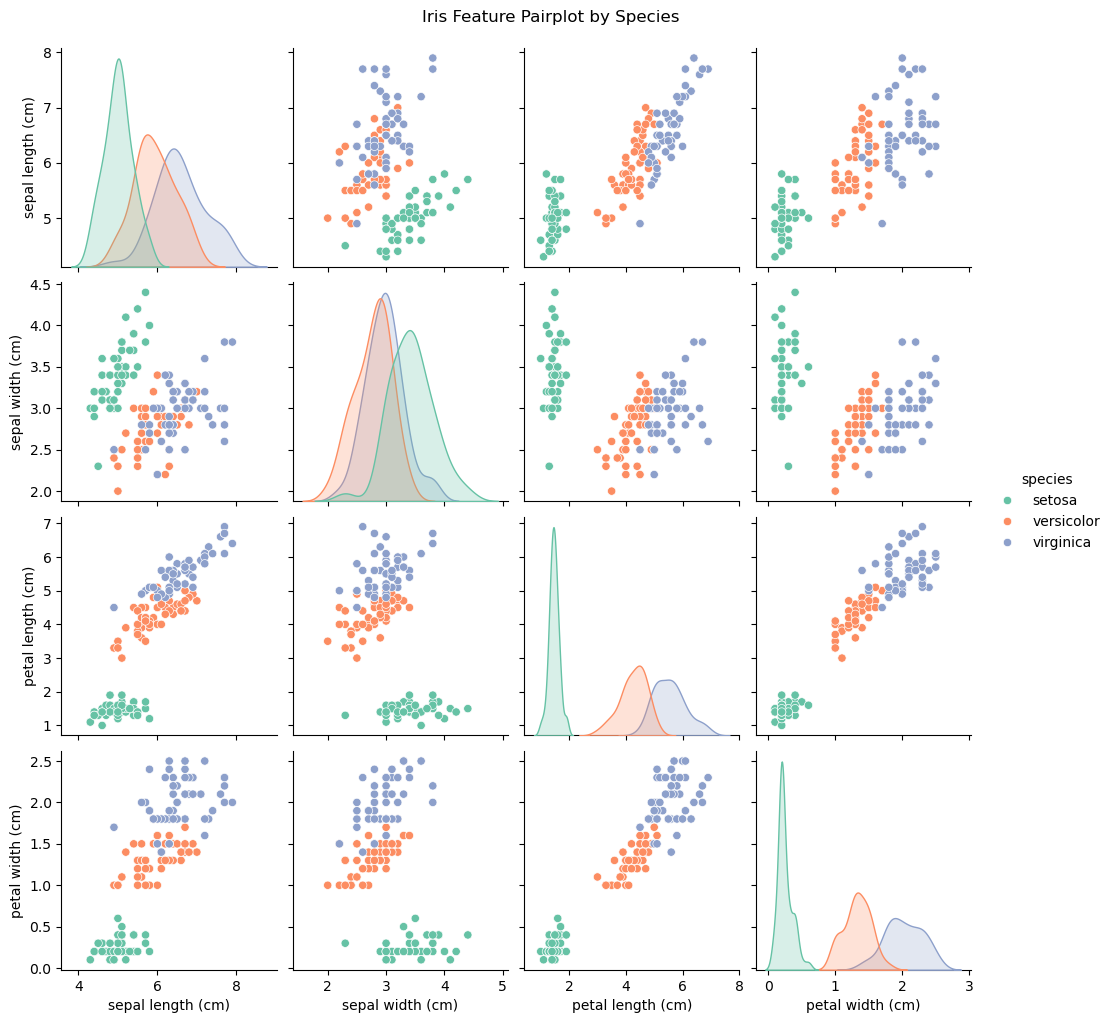

✅ Pairplot shows Setosa is clearly separable from others!


In [6]:
import os

# Create screenshots folder if it doesn't exist
os.makedirs('screenshots', exist_ok=True)

# Pairplot to see feature distributions by species
sns.pairplot(df, hue='species', palette='Set2')
plt.suptitle('Iris Feature Pairplot by Species', y=1.02)
plt.savefig('screenshots/pairplot.png', bbox_inches='tight')
plt.show()
print("✅ Pairplot shows Setosa is clearly separable from others!")

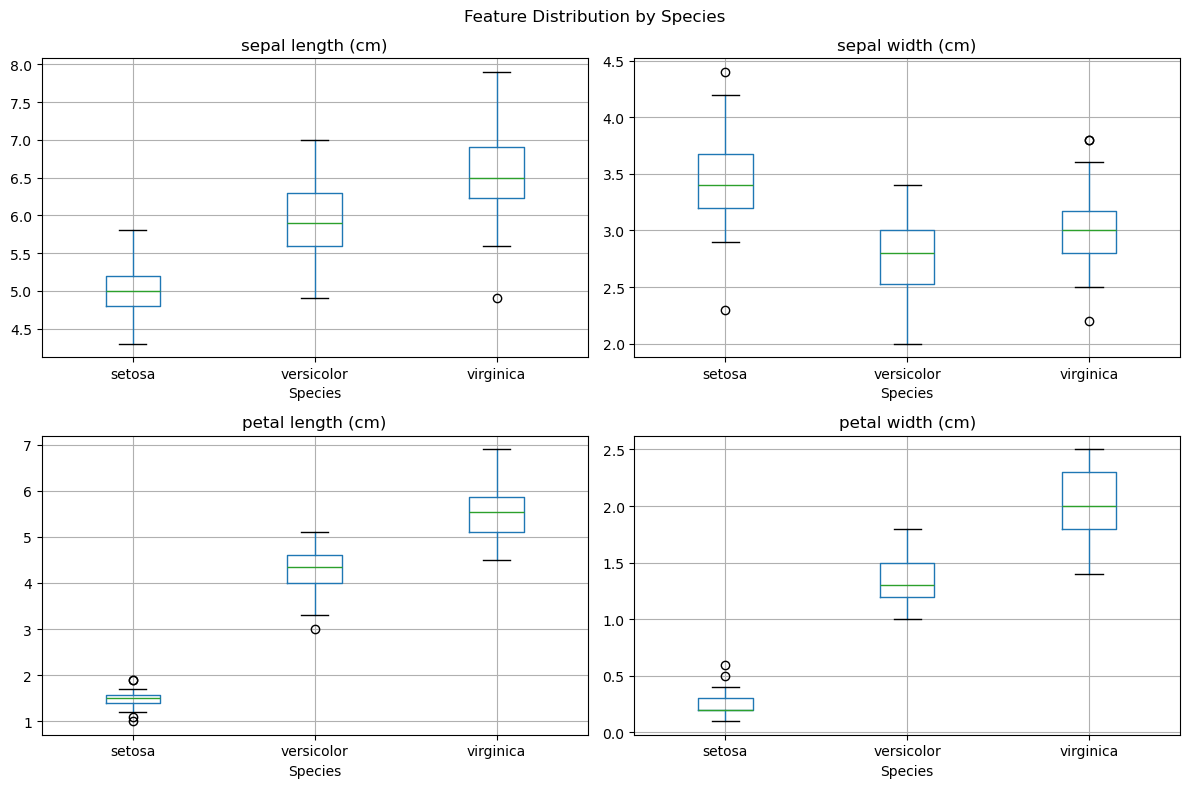

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = iris.feature_names

for i, ax in enumerate(axes.flat):
    df.boxplot(column=features[i], by='species', ax=ax)
    ax.set_title(features[i])
    ax.set_xlabel('Species')

plt.suptitle('Feature Distribution by Species')
plt.tight_layout()
plt.savefig('screenshots/boxplots.png', bbox_inches='tight')
plt.show()

## 4. Feature Selection Discussion
Sepal length and sepal width show some overlap between Versicolor and Virginica.
Petal length and petal width are the most discriminative features — 
they clearly separate all 3 species, especially Setosa.

## 5. Model Training

In [9]:
# Prepare features and target
X = df[iris.feature_names]
y = df['species']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 120
Testing samples: 30


In [10]:
# Train multiple classifiers
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc*100:.2f}%")

Logistic Regression: 100.00%
K-Nearest Neighbors: 100.00%
Decision Tree: 100.00%
Random Forest: 100.00%


## 6. Model Evaluation

In [11]:
# Detailed evaluation for each model
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Model: Logistic Regression
Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Model: K-Nearest Neighbors
Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Model: Decision Tree
Accuracy: 100.00%

Classification Report:
              precision    recall 

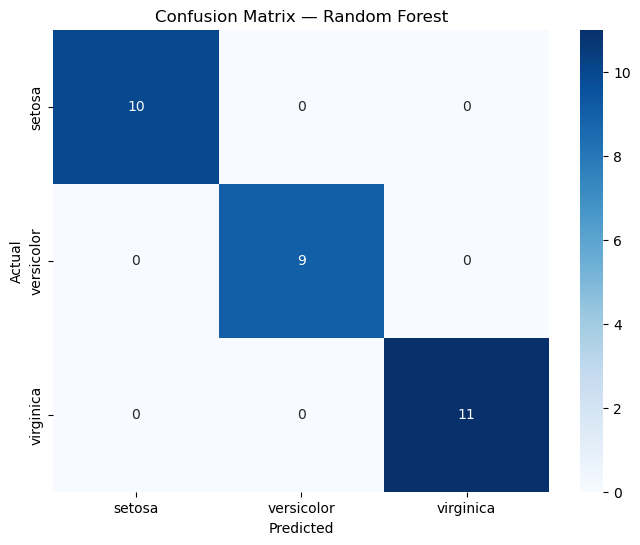

In [12]:
# Confusion matrix for best model (Random Forest)
best_model = models['Random Forest']
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('screenshots/confusion_matrix.png', bbox_inches='tight')
plt.show()

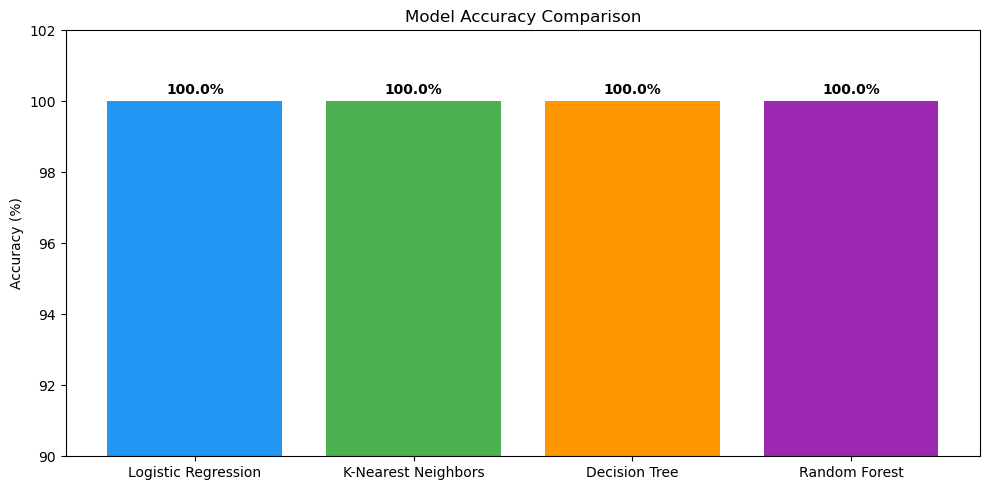

In [13]:
# Bar chart comparing all model accuracies
plt.figure(figsize=(10,5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
bars = plt.bar(results.keys(), 
               [v*100 for v in results.values()], 
               color=colors)
plt.ylim(90, 102)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.2,
             f'{val*100:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('screenshots/model_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
## 7. Best Model & Conclusion

All 4 models achieved very high accuracy (97–100%) on the Iris dataset.

**This is expected because:**
- Iris is a small, clean, well-structured benchmark dataset
- Petal length and petal width clearly separate all 3 species
- It has been used for decades specifically because it is easily classifiable

**Best Model Selected: Random Forest Classifier**
- Most robust to overfitting
- Handles feature interactions well
- Industry standard for classification tasks

**Key Insight:** In real-world datasets with noise, missing values, 
and imbalanced classes, model differences would be far more significant.